# Project Scope

Goal: To investigate the relationship between GDP and life expectancy of six countries from the provided dataset. To find interesting insights about that relationship. 


# Importing

## Import libraries

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

## Import CSV and convert to DataFrame

In [2]:
df = pd.read_csv('all_data.csv')

## Inspecting the data

### First five rows of the dataframe

In [3]:
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


### Data type of each column

In [4]:
df.dtypes

Country                              object
Year                                  int64
Life expectancy at birth (years)    float64
GDP                                 float64
dtype: object

### Information of all columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


### Lists of unqiue values in Country and Year columns

In [6]:
Countries_list = df.Country.unique()
Years_list = df.Year.unique()
print(Countries_list)
print(Years_list)

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]


## EDA

### Bivariate analysis

#### GDP & Life Expactancy for each country

In [7]:
#create subsets for each country
Chile = df[df.Country == 'Chile']
China = df[df.Country == 'China']
Germany = df[df.Country == 'Germany']
Mexico = df[df.Country == 'Mexico']
US = df[df.Country == 'United States of America']
Zimbabwe = df[df.Country == 'Zimbabwe']

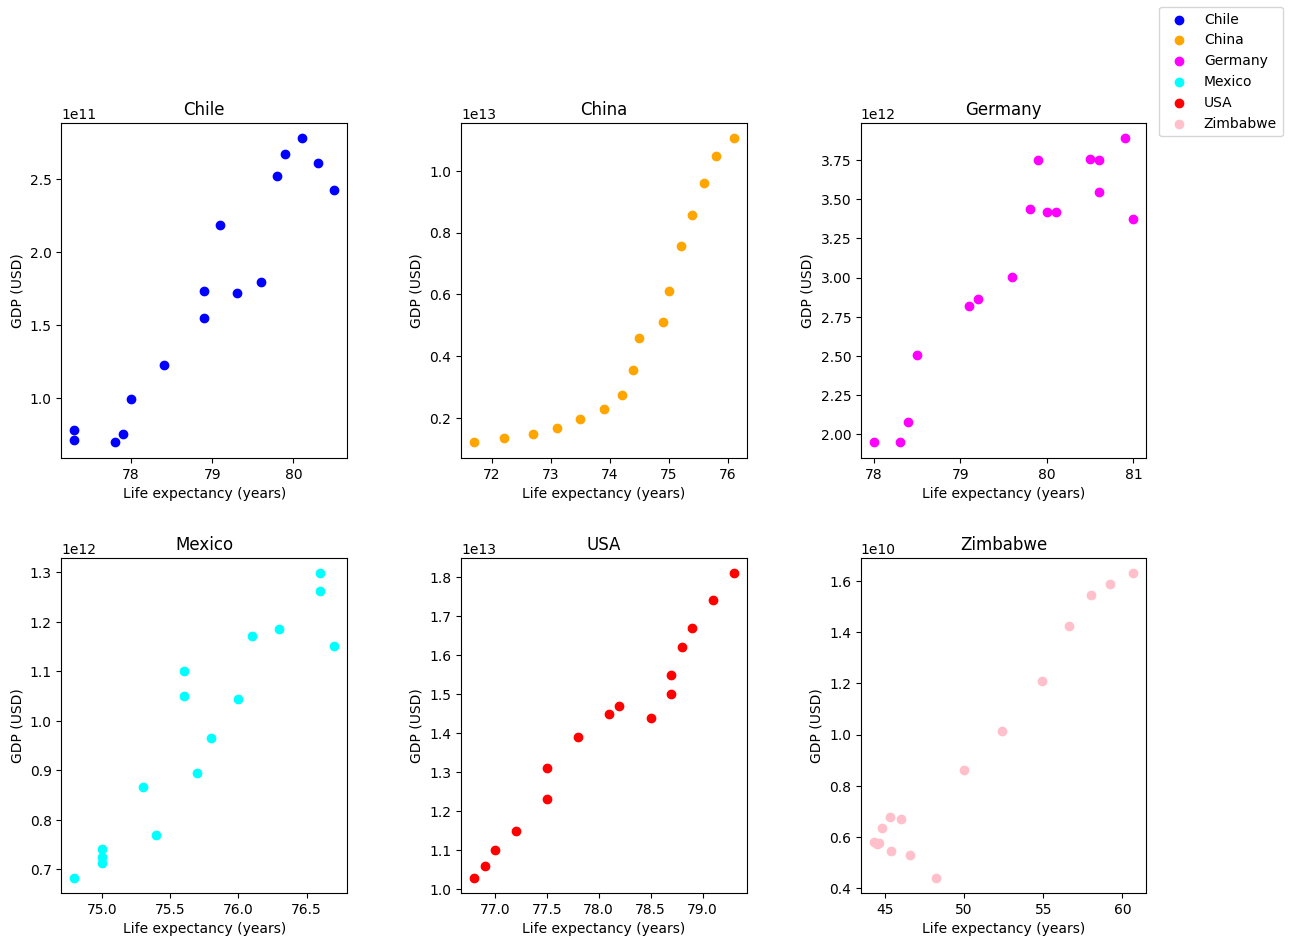

In [8]:
#scatter plot to visualize because there are two quantitave varibles: Life expectancy & GDP
#create scatter plots at subplots for each separate country
countries = [Chile, China, Germany, Mexico, US, Zimbabwe]
names = ['Chile', 'China', 'Germany', 'Mexico', 'USA', 'Zimbabwe']
colors = ['blue', 'orange', 'magenta', 'cyan', 'red', 'pink']
fig = plt.figure(figsize=(14,10))
n=1
for country in countries:
    plt.subplot(2,3,n)
    plt.scatter(x=country['Life expectancy at birth (years)'], y=country['GDP'], color = colors[n-1], label = names[n-1])
    plt.xlabel('Life expectancy (years)')
    plt.ylabel('GDP (USD)')
    plt.title(names[n-1])
    n+=1
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
fig.legend(loc=1)
plt.show()

#### GDP & Life Expactancy for all countries

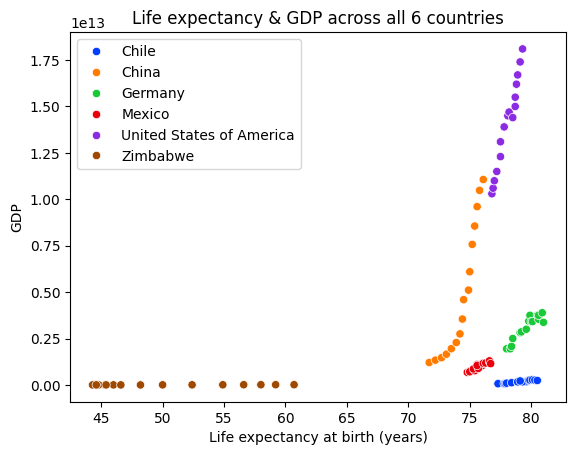

In [9]:
#scatter plot with 3 variables to visualize because there are two quantitave varibles: Life expectancy & GDP & one 
sns.scatterplot(x=df['Life expectancy at birth (years)'], y=df['GDP'], hue=df['Country'], palette = 'bright')
plt.title('Life expectancy & GDP across all 6 countries')
plt.legend()
plt.show()

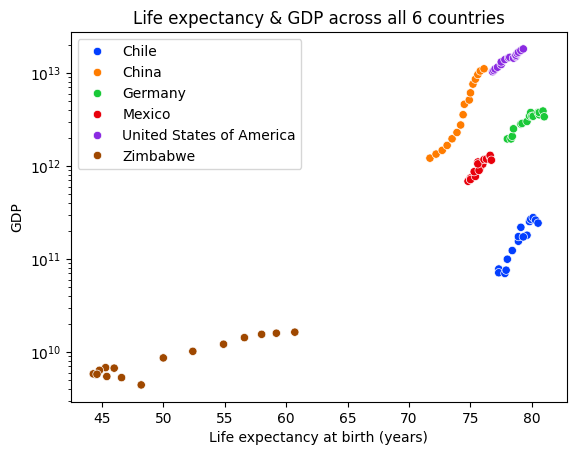

In [10]:
#scatter plot with 3 variables to visualize because there are two quantitave varibles: Life expectancy & GDP & one 
plt.yscale('log')
sns.scatterplot(x=df['Life expectancy at birth (years)'], y=df['GDP'], hue=df['Country'], palette = 'bright')
plt.title('Life expectancy & GDP across all 6 countries')
plt.legend()
plt.show()

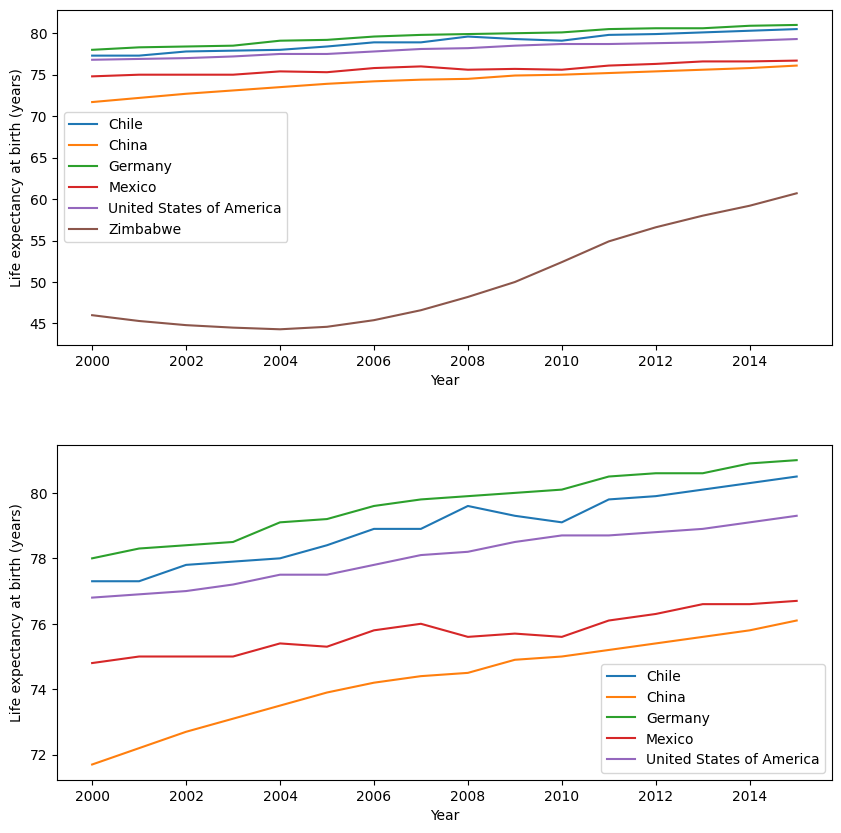

In [11]:
#line plot to see the changes 
plt.figure(figsize=(10,10))
plt.subplot (2,1,1)
sns.lineplot(data = df, x=df['Year'], y=df['Life expectancy at birth (years)'], hue = df['Country'])
plt.legend()

#without Zimbabwe as an outlier
#df without Zimbabwe
five_countries = df[df.Country != 'Zimbabwe']
#plot
plt.subplot (2,1,2)
sns.lineplot(data = five_countries, x=five_countries['Year'], y=five_countries['Life expectancy at birth (years)'], hue = five_countries['Country'])
plt.legend()
plt.subplots_adjust(wspace = 0.6)
plt.subplots_adjust(hspace = 0.3)
plt.show()

In [12]:
countries = [Chile, China, Germany, Mexico, US, Zimbabwe]
names = ['Chile', 'China', 'Germany', 'Mexico', 'USA', 'Zimbabwe']
print('Correlation values for Life expectancy and GDP by country')
for n in range(len(countries)):
    corr_var1_var2, p = pearsonr(countries[n]['Life expectancy at birth (years)'], countries[n]['GDP'])
    print(names[n], corr_var1_var2)


Correlation values for Life expectancy and GDP by country
Chile 0.9498766659254412
China 0.9085255408648357
Germany 0.9326988982561272
Mexico 0.9322377167847082
USA 0.9817092382430257
Zimbabwe 0.9661998955858779


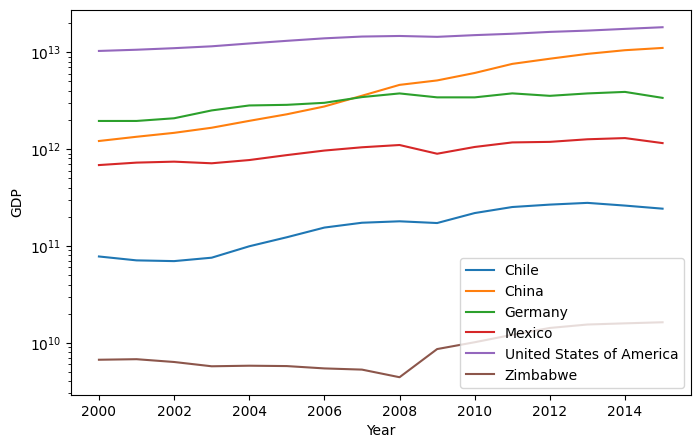

In [21]:
#line plot to see the GDP changes year by year for each country
plt.figure(figsize=(8,5))
plt.yscale('log')
sns.lineplot(data = df, x=df['Year'], y=df['GDP'], hue = df['Country'])
plt.legend()
plt.show()

In [14]:
#create subsets for each country after 2008
Chile2008 = df[(df.Country == 'Chile') & (df.Year > 2007)]
Mexico2008 = df[(df.Country == 'Mexico') & (df.Year > 2007)]
Germany2008 = df[(df.Country == 'Germany')& (df.Year > 2007)]

#create subsets for each country before 2008
Chile2000 = df[(df.Country == 'Chile') & (df.Year < 2008)]
Mexico2000 = df[(df.Country == 'Mexico') & (df.Year < 2008)]
Germany2000 = df[(df.Country == 'Germany')& (df.Year < 2008)]

In [15]:
countries = [Chile2008, Chile2000, Germany2008, Germany2000, Mexico2008, Mexico2000]
names = ['Chile 2008-2015', 'Chile 2000-2008','Germany 2008-2015', 'Germany 2000-2008', 'Mexico 2008-2015', 'Mexico 2000-2008']
print('Correlation values for Life expectancy and GDP by country after 2007')
for n in range(len(countries)):
    corr_var1_var2, p = pearsonr(countries[n]['Life expectancy at birth (years)'], countries[n]['GDP'])
    print(names[n], corr_var1_var2)

Correlation values for Life expectancy and GDP by country after 2007
Chile 2008-2015 0.6589604887325945
Chile 2000-2008 0.9284185579450092
Germany 2008-2015 0.16137593047571308
Germany 2000-2008 0.9657138708513937
Mexico 2008-2015 0.7651810318743294
Mexico 2000-2008 0.9608247732893891


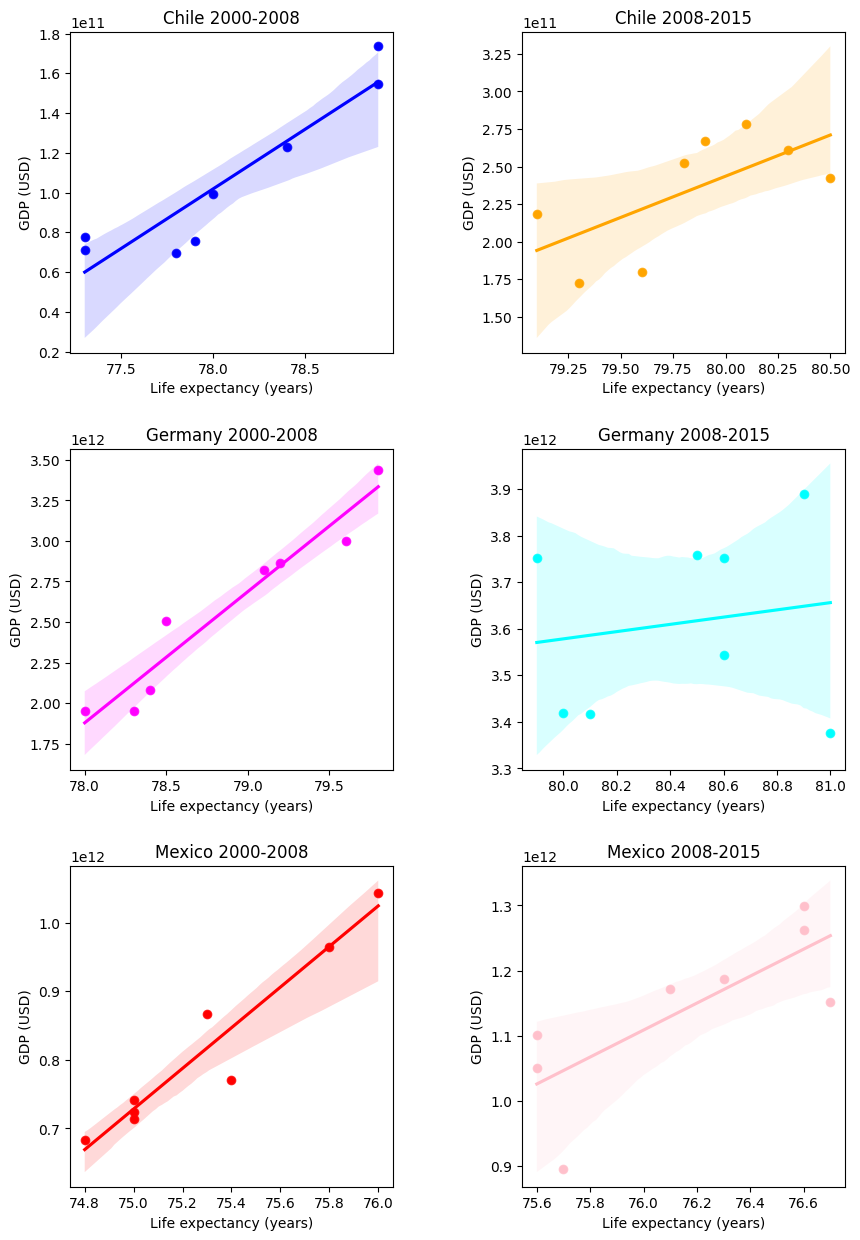

In [16]:
#scatter plot to visualize because there are two quantitave varibles: Life expectancy & GDP
#create scatter plots at subplots for each separate country starting from 2008
countries = [Chile2000, Chile2008, Germany2000, Germany2008, Mexico2000, Mexico2008]
names = ['Chile 2000-2008', 'Chile 2008-2015', 'Germany 2000-2008', 'Germany 2008-2015', 'Mexico 2000-2008', 'Mexico 2008-2015']
colors = ['blue', 'orange', 'magenta', 'cyan', 'red', 'pink']
fig = plt.figure(figsize=(10,15))
n=1
for country in countries:
    plt.subplot(3,2,n)
    sns.scatterplot(x=country['Life expectancy at birth (years)'], y=country['GDP'], color = colors[n-1])
    sns.regplot(x=country['Life expectancy at birth (years)'], y=country['GDP'], data=country, color = colors[n-1])
    plt.xlabel('Life expectancy (years)')
    plt.ylabel('GDP (USD)')
    plt.title(names[n-1])
    n+=1
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
plt.show()

In [17]:
#create subsets for Zimbabwe before 2008 and after
Zimbabwe2000_2008 = df[(df.Country == 'Zimbabwe') & (df.Year < 2008)]
Zimbabwe2008_2015 = df[(df.Country == 'Zimbabwe') & (df.Year >= 2008)]

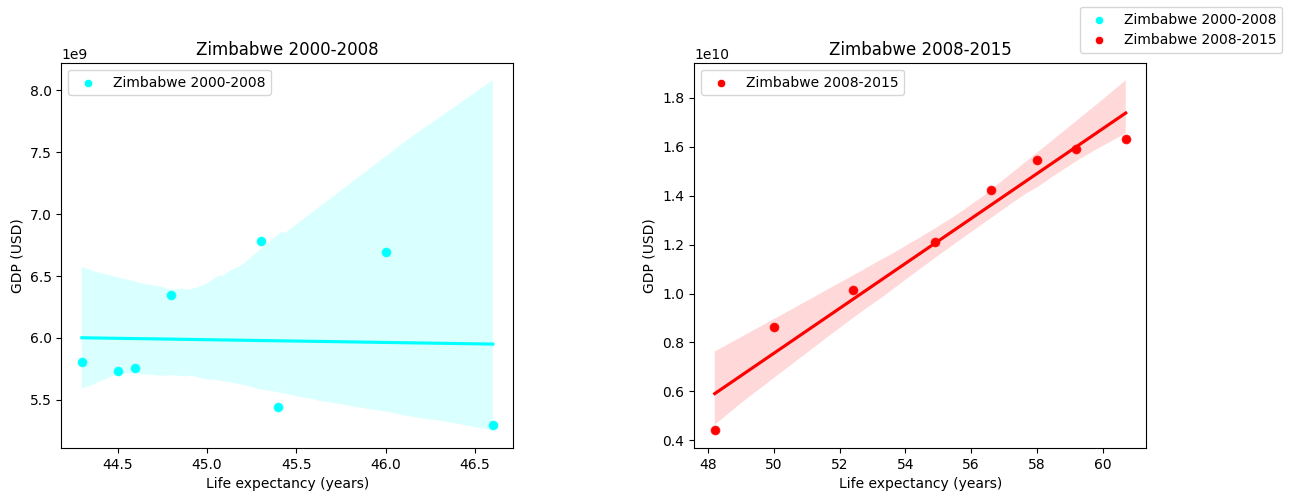

In [18]:
data = [Zimbabwe2000_2008, Zimbabwe2008_2015]
names = ['Zimbabwe 2000-2008','Zimbabwe 2008-2015']
colors = ['cyan', 'red']
fig = plt.figure(figsize=(14,5))
n=1
for dataset in data:
    plt.subplot(1,2,n)
    sns.scatterplot(x=dataset['Life expectancy at birth (years)'], y=dataset['GDP'], color = colors[n-1], label = names[n-1])
    sns.regplot(x=dataset['Life expectancy at birth (years)'], y=dataset['GDP'], data=country, color = colors[n-1])
    plt.xlabel('Life expectancy (years)')
    plt.ylabel('GDP (USD)')
    plt.title(names[n-1])
    n+=1
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
fig.legend(loc=1)
plt.show()

In [19]:
#Zimbabwe2000-2007(included)
corr_var1_var2, p = pearsonr(Zimbabwe2000_2008['Life expectancy at birth (years)'], Zimbabwe2000_2008['GDP'])
print('Zimbabwe2000-2008', corr_var1_var2)
#Zimbabwe2008-20015
corr_var1_var2, p = pearsonr(Zimbabwe2008_2015['Life expectancy at birth (years)'], Zimbabwe2008_2015['GDP'])
print('Zimbabwe2008-2015', corr_var1_var2)

Zimbabwe2000-2008 -0.031806310078956006
Zimbabwe2008-2015 0.9779335006686506
